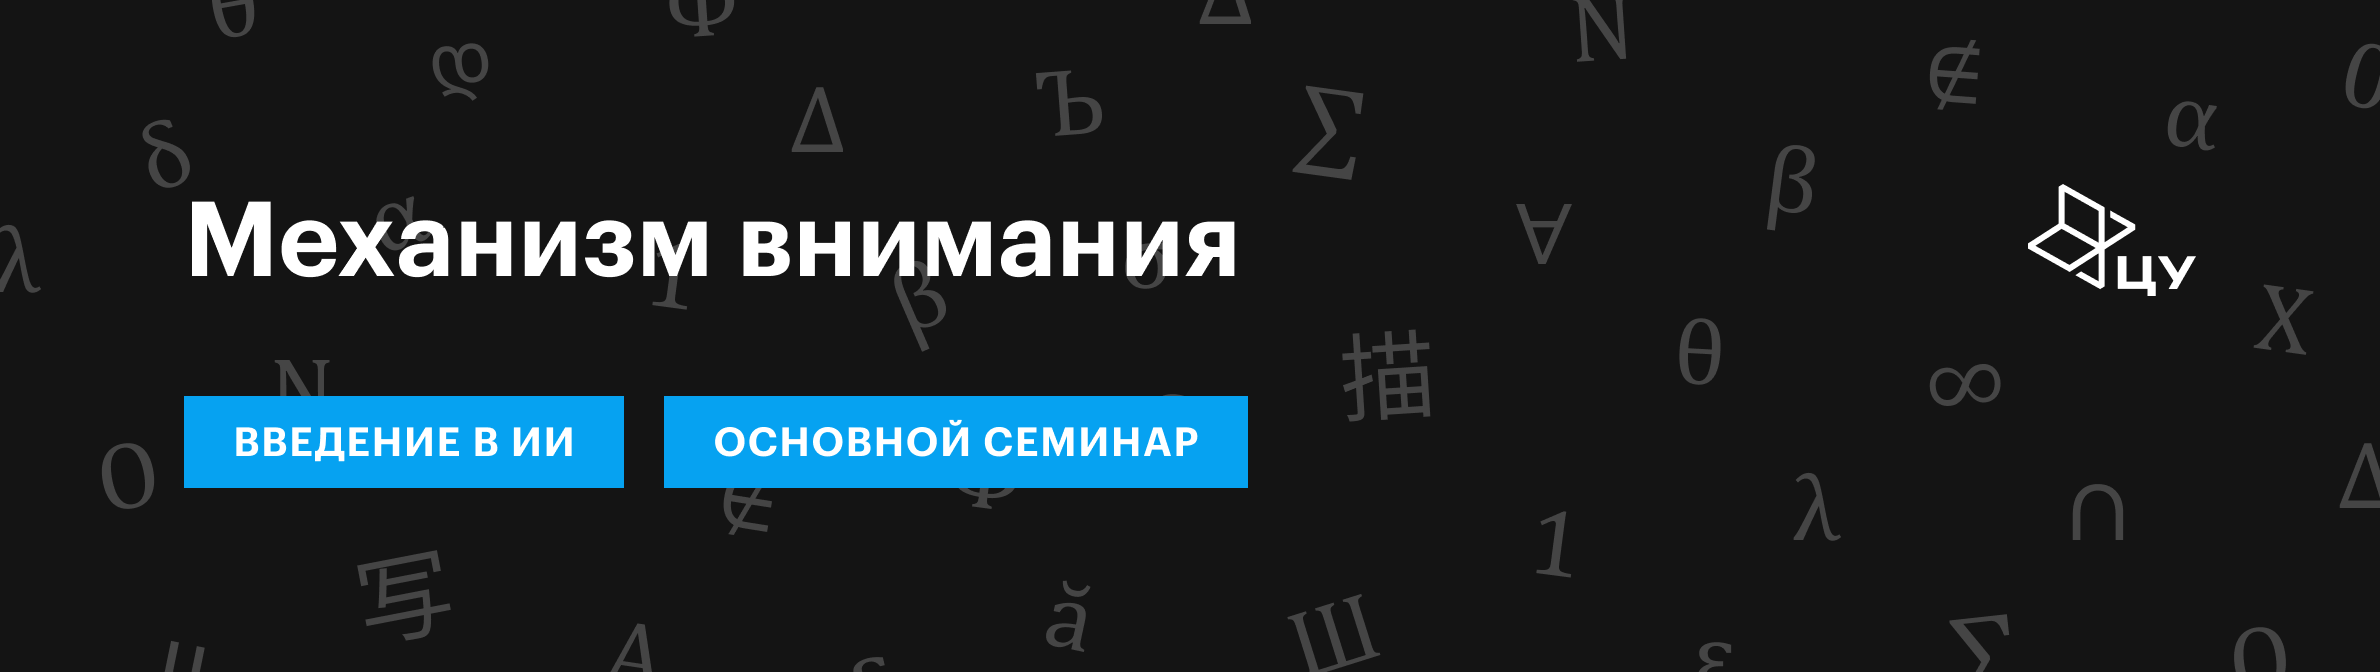

# Семинар по теме «Механизм внимания»

Сегодня ты познакомишься с возможностями популярной платформы Hugging Face, где собраны языковые и другие модели.

С их помощью решим задачу классификации сентимента коротких текстовых сообщений:

*   получим эмбеддинги из нейросети и обучим на них логистическую регрессию;
*   применим нейросеть для классификации сентимента без дополнительного обучения;
*   используем чатовую LLM и решим задачу с помощью промпта.


## Подготовка данных

Начнём с импорта пакетов и загрузки датасета.

In [ ]:
import pandas as pd
import numpy as np

pandas умеет загружать файлы не только с локального диска, но и по ссылке из интернета. Мы укажем путь к parquet-файлу, который хранится на платформе Hugging Face.


In [ ]:
df = pd.read_parquet("hf://datasets/sy-volkov/russian-sentiment-analysis-dataset/data/train-00000-of-00001.parquet")

In [ ]:
df

,processed_text,Class,label,__index_level_0__
0,"Алексей, С Днем Рождения!!! Исполнения всего з...",G,1,0
1,С Днём Рождения!,G,1,1
2,"Староста, с днюхой!",G,1,2
3,"Коля, мои поздравления! Желаю хороших отпусков...",G,1,3
4,"Леша, поздравляю! Всех благ!",G,1,4
...,...,...,...,...
3868,"С нетерпением жду, когда смогу тебя поздравить...",G,1,3892
3869,"Это отличная новость, дай Бог всего самого хор...",G,1,3893
3870,С праздником! Пусть каждый день приносит радость!,G,1,3894
3871,Ты заслуживаешь самых теплых слов и поздравлений!,G,1,3895


В датасете есть информативные колонки:

- `processed_text` — текст, для которого нужно определить сентимент;
- `label` — сентимент текста в целых числах. 0 — нейтральный, 1 — положительный, 2 — негативный.

Остальные колонки нас не интересуют: `Class` дублирует `label`, а `__index_level_0__` — просто индексная колонка.

In [ ]:
df.drop(columns=['Class', '__index_level_0__'], inplace=True)

Разделим датасет на обучающую и тестовую подвыборки.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['processed_text'], df['label'], stratify=df['label'], random_state=123, train_size=0.75)

Теперь можно приступать к решению задачи

## Получение эмбеддингов из Hugging Face

На платформе Hugging Face доступны модели, которые умеют классифицировать сентимент текста.

Их можно использовать двумя способами:
*   напрямую — получать предсказание модели без дополнительного обучения;
*   как эмбеддер — извлекать эмбеддинги и обучать на них классические модели машинного обучения.




Начнём с обзора возможностей [Hugging Face](https://huggingface.co/).


### Шаг 1. Поиск подходящей модели

Чтобы подобрать модель под наш датасет, воспользуемся поисковой строкой в верхней части сайта. Нам нужна модель для классификации сентимента на русском языке, поэтому сформулируем поисковый запрос.


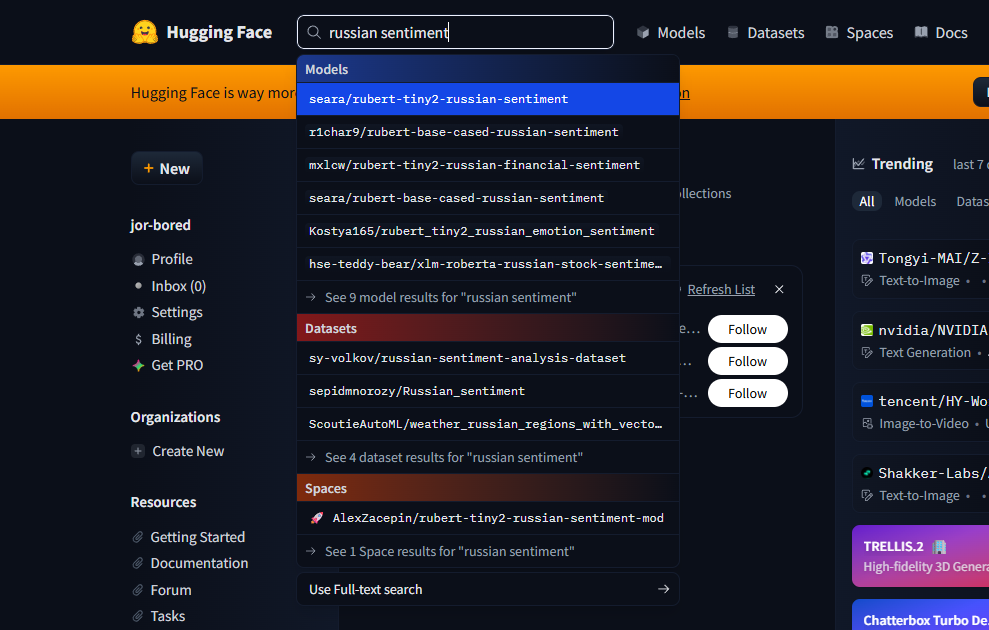

### Шаг 2. Проверка модели

Важно убедиться, что выбранная модель подходит под нашу задачу, потому что сентимент бывает у разных текстов. Например, финансовый для предсказания динамики акций или эмоциональный, как в нашем кейсе.

Как понять, на каких текстах обучена модель? Иногда это указано прямо в назывании, но чаще всего более детальную информацию о модели можно найти в её карточке.

Например, откроем карточку самой [1-й модели из поиска](https://huggingface.co/seara/rubert-tiny2-russian-sentiment).



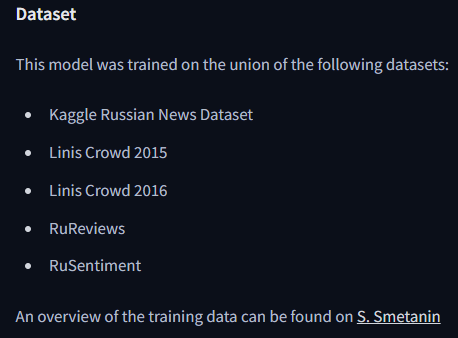

В карточке модели перечислены датасеты, на которых она обучалась. По их описанию можно понять, из каких текстов они состоят и подходит ли модель для анализа сентимента.

Представленные датасеты нам не совсем подходят. Но чтобы рассмотреть возможные ограничения, мы используем эту модель.


### Шаг 3. Загрузка модели

Загрузим модель с помощью transformers — официальной библиотеки Hugging Face.

Библиотеку назвали в честь архитектуры трансформера, потому что большинство современных моделей на Hugging Face основаны на этом типе нейросетей.

Инструкцию по использованию модели также можно найти в её карточке.


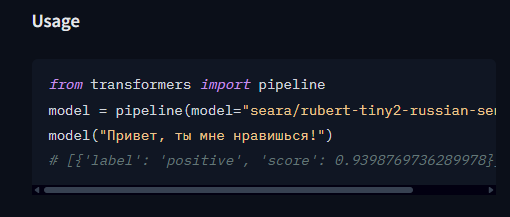

Если инструкции нет в описании, открой шапку карточки модели и нажми кнопку `Use this model`.

В выпадающем списке выбери `Transformers` — так мы будем использовать официальную библиотеку Hugging Face.


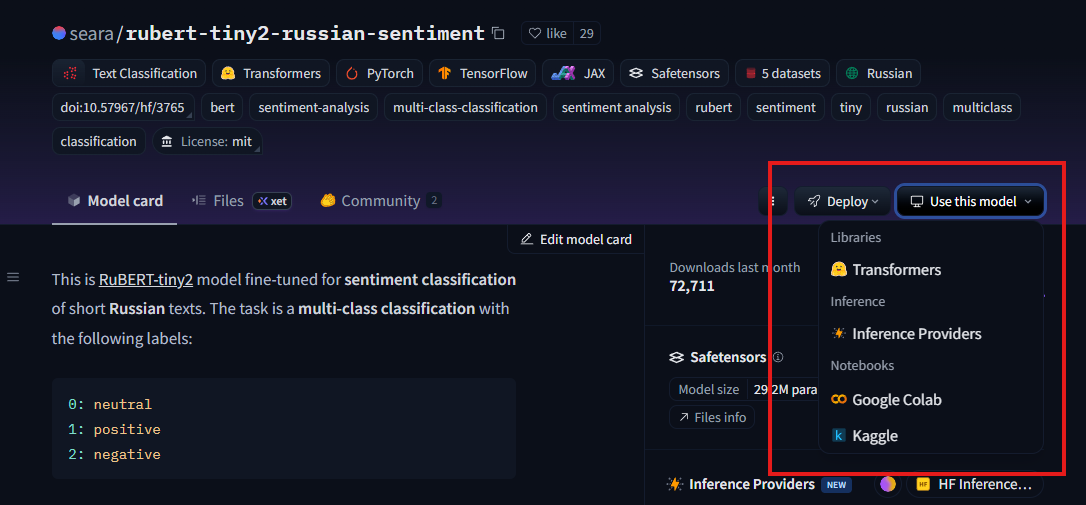

### Шаг 4. Способы использования модели

Hugging Face предлагает два способа работать с моделью:

*   через `pipeline` — самый простой вариант: достаточно передать список текстов на вход;
*   через `AutoTokenizer` и `AutoModelForSequenceClassification`. Этот способ даёт больше контроля над токенизацией и работой модели.


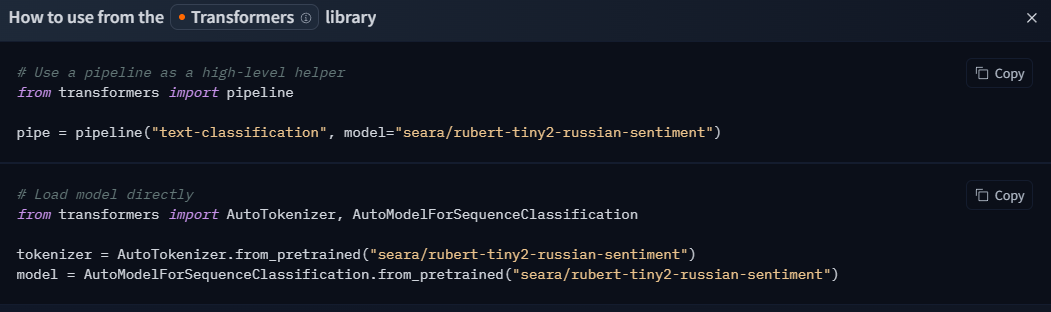

### Шаг 5. Получение эмбеддингов через pipeline

Будем использовать первый способ — через `pipeline`. Он решает нашу задачу и требует минимум кода.

При этом начнём не с классификации текстов, а с получения эмбеддингов. Несмотря на рекомендации в карточке модели, это можно сделать напрямую: `pipeline` поддерживает извлечение эмбеддингов и другие сценарии работы с языковыми моделями.



**Важно.** Если модель формально можно запустить через `pipeline` для другой задачи, это не означает, что она будет работать корректно.

Например, модель для классификации текстов плохо подходит для задачи маскированного языкового моделирования. Выходные слои таких моделей обучаются по-разному и не взаимозаменяемы.

В нашем случае проблем не возникнет: получение эмбеддингов и классификация используют общую базовую часть модели. Классификационный слой — это лишь небольшая надстройка над эмбеддингами.


### Шаг 6. Настройка pipeline

Перейдём к использованию `pipeline`. У него много аргументов — полный список есть в документации. Для нашего семинара достаточно знать основные.

*   `task` — тип задачи. В нашем случае — `feature-extraction`.
*   `model` — название модели в Hugging Face.
*   `pipeline_class` — класс пайплайна для получения эмбеддингов. Мы используем собственную реализацию.
*   `dtype` — формат весов модели. Например, fp16 ускоряет вычисления и снижает потребление памяти по сравнению с fp32.
*   `batch_size` — размер батча. Если передать в модель сразу все данные, может не хватить памяти.


Попробуем применить `pipeline` к тексту из нашего датасета.

In [ ]:
import torch
from transformers import pipeline

pipe = pipeline(task="feature-extraction",
                model="seara/rubert-tiny2-russian-sentiment",
                dtype=torch.float16, batch_size=128)

config.json:   0%|          | 0.00/911 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/117M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: seara/rubert-tiny2-russian-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
np.array(pipe(X_train.to_list()[0])).shape, X_train.to_list()[0]

((1, 17, 312),
 'Наблюдение за портретным сходством может дать много информации о семейных чертах.')

Токены паддинга можно увидеть, если токенизировать одно предложение.



In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("seara/rubert-tiny2-russian-sentiment")

tokenizer([X_train.to_list()[0]],  padding='max_length') # Паддим до максимальной длины модели

{'input_ids': [[2, 1041, 30983, 650, 25097, 1635, 48968, 656, 3960, 30583, 4064, 9280, 326, 43434, 77288, 18, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

**Вопрос.** Почему длина эмбеддинга (вторая размерность) получилась такой большой — 214 токенов, хотя входное предложение заметно короче?


### Ответ для семинариста
Трансформер работает с последовательностями фиксированной длины: все внутренние размерности модели заданы заранее.

Если входная последовательность короче максимальной длины, её дополняют специальными токенами паддинга.


Оказывается, у нас может быть очень много паддинга!

### Задание 1. Реализация mean pooling

У нас получилось для одного текста 214 эмбеддингов, но нужен всего один. Просто усреднить кажется плохой идеей, потому что в усреднение также попадут токены, которые отвечают за паддинг, то есть они частично испортят информацию.

Нужно получить один эмбеддинг из 214. Самый популярный способ сделать это — `mean_pooling`. То есть усреднение ведётся не по всем токенам на выходе модели, а только по тем, которые не соответствуют паддингу.

Мы можем немного модифицировать пайплайн, переопределив в нём функцию `_forward`, где произведём усреднение.

В этом задании реализуй `mean_pooling`: сложи эмбеддинги всех токенов, кроме паддинга, и раздели результат на их количество.


### Ответ для семинариста

In [ ]:
# Класс, который работает под капотом pipeline, когда передаем task='feature-extract'
from transformers import FeatureExtractionPipeline

# Доопределим пайплайн, чтобы он возвращал нам один эмбеддинг, а не все эмбеддинги выходного слоя
class MeanPoolingPipeline(FeatureExtractionPipeline):
    def _forward(self, model_inputs):
        outputs = self.model(**model_inputs)

        hidden = outputs.last_hidden_state  # (B, T, D)
        mask = model_inputs["attention_mask"].unsqueeze(-1).type_as(hidden)

        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        return pooled  # (B, D)

Запустим полученный пайплайн на всем датасете.

In [ ]:
# Добавим аргумент для кастомного пайплайна
pipe = pipeline(task="feature-extraction",
                model="seara/rubert-tiny2-russian-sentiment",
                pipeline_class=MeanPoolingPipeline,
                dtype=torch.float16, batch_size=128)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: seara/rubert-tiny2-russian-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Применим pipeline и сразу обернем эмбеддинги в np.array
X_train_embs = np.array(pipe(X_train.to_list()))
X_test_embs = pipe(X_test.to_list())

In [ ]:
# Все получилось верно
X_train_embs.shape

(2904, 312)

### Задание 2. Обучение логистической регрессии

Обучи логистическую регрессию на полученных эмбеддингах и оцени её качество. Перед обучением эмбеддинги нужно нормализовать — это улучшает сходимость модели.

1.   Нормализуй эмбеддинги. Обрати внимание, по какой выборке нужно вычислять среднее и стандартное отклонение.
2.   Обучи логистическую регрессию.
3. Получи предсказания модели.
4. Оцени качество по метрике Accuracy.


### Ответ для семинариста

In [ ]:
# Импортируем необходимый функционал
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

# Нормализуем данные данные, потому что иначе будут проблемы с сходимостью
mean_train = X_train_embs.mean(axis=0)
std_train = X_train_embs.std(axis=0)

# Если данных много или эмбеддинги очень большие, то можно батчами обрабатывать
X_train_embs = (X_train_embs - mean_train) / std_train
X_test_embs = (X_test_embs - mean_train) / std_train

# Инициализируем и обучаем модель
model = LogisticRegression(max_iter=500)
model.fit(X_train_embs, y_train)

# Получаем предсказания
y_train_preds = model.predict(X_train_embs)
y_test_preds = model.predict(X_test_embs)

# Оценим качество
print(f'Точночть на обучающей выборке: {round(accuracy_score(y_train, y_train_preds), 4)*100}%')
print(f'Точночть на тестовой выборке: {round(accuracy_score(y_test, y_test_preds), 4)*100}%')

### Задание 3. Использование модели напрямую

Качество классификации оказалось достаточно высоким, но для этого нам пришлось обучать логистическую регрессию. Для обучения ML-модели необходима разметка, но она далеко не всегда есть для текстовых данных.

В таких случаях используют готовые модели для анализа сентимента из открытых источников и проверяют, насколько хорошо они работают на новой задаче.

1. Загрузи [ту же модель](https://huggingface.co/seara/rubert-tiny2-russian-sentiment) — теперь как классификатор текстов.

2. Получи её ответы. Дополнительный код писать не нужно.

3. Приведи ответы модели к разметке нашего датасета.

4. Оцени качество по метрике Accuracy.


### Ответ для семинариста

In [ ]:
# Инициализируем новый пайплайн
pipe = pipeline("text-classification", model="seara/rubert-tiny2-russian-sentiment", dtype=torch.float16, batch_size=128)

# mapper для преобразования ответов модели к разметке датасета
mapper = {'neutral': 0, 'positive': 1, 'negative': 2}

# Получим предсказания
y_train_preds = [mapper[el['label']] for el in pipe(X_train.to_list())]
y_test_preds = [mapper[el['label']] for el in pipe(X_test.to_list())]

# Оценим качество
print(f'Точность на обучающей выборке: {round(accuracy_score(y_train, y_train_preds), 4)}%')
print(f'Точность на тестовой выборке: {round(accuracy_score(y_test, y_test_preds), 4)}%')

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: seara/rubert-tiny2-russian-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Точность на обучающей выборке: 0.7342%
Точность на тестовой выборке: 0.7379%


Качество существенно снизилось.

**Вопрос.** Можно ли сказать, что выбранная модель совсем «плохая»? Где возникает основная проблема, мешающая корректно классифицировать тексты?

### Ответ для семинариста

Основная проблема связана с последним классификационным слоем. Именно из-за него качество оказывается ниже.

Когда мы обучали логистическую регрессию на эмбеддингах, мы фактически переобучили этот слой и получили более высокое качество. Это означает, что эмбеддер работает достаточно хорошо, а исходный классификационный слой — хуже.

Если разметки нет, переобучить финальный слой невозможно.


## Использование LLM

Что делать, если хочется получить качественное решение задачи, но для датасета нет подходящей модели? В таком случае можно попробовать чатовые LLM: с помощью промпта попросить модель решить поставленную задачу.

Такие модели достаточно велики, чтобы качественно решать самые разные текстовые задачи.

У этого подхода есть две проблемы:
*   большая модель требует больше ресурсов, хотя Colab для такой задачи подойдёт;
*   задача решается не напрямую, а через Seq2Seq. Это значит, что модель возвращает не целевую метку, а некоторую последовательность символов. Из-за этого появляется пространство для галлюцинаций: модель может отклониться от промпта.


### Шаг 1. Установка и подготовка llama_cpp_python
Проще всего использовать LLM через `llama.cpp`, для которого существует API в Python `llama_cpp_python`. Данный функционал позволяет использовать модели в формате GGUF максимально эффективно и быстро.

Мы будем использовать данный пакет на GPU. Сначала нужно выяснить версию CUDA, чтобы скачать совместимую версию.

In [ ]:
# Выясняем версию CUDA
!nvidia-smi

Wed Mar 18 21:45:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P0             59W /   70W |    6017MiB /  15360MiB |     24%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

В коллабе сейчас установлена версия 13.0. Для неё нет официального whl-файл с `llama_cpp_python`. Поэтому автор семинара сам скомпилировал нужную версию.

Можно скачать через `pip install llama-cpp-python`, но будет долго компилироваться.

Или можно скачать уже скомпилированную официальную версию для CUDA 12.1-12.5.

In [ ]:
!gdown 1B6NZjcN02HllooO3KTxa6QXJOt1mP1LJ
!pip install /content/llama_cpp_python-0.3.16-cp312-cp312-linux_x86_64.whl

Processing ./llama_cpp_python-0.3.16-cp312-cp312-linux_x86_64.whl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [llama-cpp-python]


### Шаг 2. Загрузка LLM

Теперь можно использовать пакет.

В качестве модели возьмём [Yandex GPT5 Lite Instruct](https://huggingface.co/yandex/YandexGPT-5-Lite-8B-instruct-GGUF)
. Это относительно небольшая модель на 8 млрд параметров от Яндекса.

Для неё доступна официальная квантованная версия. Квантизация ускоряет работу модели и снижает потребление памяти при минимальной потере качества.

Загрузим модель.


In [ ]:
from llama_cpp import Llama

llm = Llama.from_pretrained(
	repo_id="yandex/YandexGPT-5-Lite-8B-instruct-GGUF", # Название модели
	filename="YandexGPT-5-Lite-8B-instruct-Q4_K_M.gguf", # Хотим квантизованную до 4 бит версию
  n_ctx=2048, # Максимальный размер контекстного окна (сколько токенов можно передать в модель)
  n_gpu_layers=-1, # Всё кладём на GPU
	n_threads=2, # Количество ядер процессора
	verbose=False # Не хотим получать логи (они нам не нужны)
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


./YandexGPT-5-Lite-8B-instruct-Q4_K_M.gg(…):   0%|          | 0.00/4.92G [00:00<?, ?B/s]

llama_context: n_ctx_per_seq (2048) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


### Шаг 3. Формирование промпта в ChatML
Теперь проверим, что всё работает.

Промпты для таких моделей необходимо подавать в специальном формате ChatML (Chat Markup Language).

Этот формат используется под капотом в популярных OpenAI API, Anthropic Claude и многих других LLM. Он позволяет сохранять историю диалога и контекст для более качественных ответов.

Основная идея ChatML — разделение сообщений по ролям:

*   `user` — сообщение от пользователя;
*   `assistant` — ответ LLM.  Если передать его обратно на вход, модель «видит» предыдущий диалог и учитывает его в следующем ответе;
*    `system` — системный промпт. Он регулирует поведение модели, чтобы модель, например, была хорошим помощником и не материлась.


In [ ]:
# Зададим промпт в формате ChatML
messages = [{"role": "user", "content": "В чем смысл жизни?"}]

# Подаём на вход модели и смотрим на результат
result = llm.create_chat_completion(
    messages = messages
    )
result

{'id': 'chatcmpl-f580b801-5fea-44bf-a249-86e8a5e691a2',
 'object': 'chat.completion',
 'created': 1773876166,
 'model': '/root/.cache/huggingface/hub/models--yandex--YandexGPT-5-Lite-8B-instruct-GGUF/snapshots/9fe287d2f512503046bb008aed350f2b4bbb903d/./YandexGPT-5-Lite-8B-instruct-Q4_K_M.gguf',
 'choices': [{'index': 0,
   'message': {'role': 'assistant',
    'content': ' Вопрос о смысле жизни является одним из самых глубоких и философских вопросов, на который нет универсального ответа. Каждый человек может найти свой собственный смысл жизни, который будет соответствовать его ценностям, убеждениям и жизненному опыту.\n\nНекоторые люди могут видеть смысл жизни в достижении определённых целей, таких как карьера, семья, здоровье или материальное благополучие. Другие могут находить смысл в творчестве, духовном развитии, помощи другим людям или служении обществу.\n\nВажно помнить, что смысл жизни может меняться со временем и в зависимости от обстоятельств. Поэтому важно постоянно искать и н

Здесь много разной метаинформации, но нас интересует только текст. Достанем его.

In [ ]:
result['choices'][0]['message']['content']

' Вопрос о смысле жизни является одним из самых глубоких и философских вопросов, на который нет универсального ответа. Каждый человек может найти свой собственный смысл жизни, который будет соответствовать его ценностям, убеждениям и жизненному опыту.\n\nНекоторые люди могут видеть смысл жизни в достижении определённых целей, таких как карьера, семья, здоровье или материальное благополучие. Другие могут находить смысл в творчестве, духовном развитии, помощи другим людям или служении обществу.\n\nВажно помнить, что смысл жизни может меняться со временем и в зависимости от обстоятельств. Поэтому важно постоянно искать и находить новые источники смысла и удовлетворения в жизни.'

### Задание 4. Классификация сентимента с помощью LLM

Теперь получим разметку для нашего датасета с помощью LLM. Для этого нужно следующее.

1. Придумать промпт, который описывает задачу. Его модель будет получать вместе с каждым сообщением из датасета. В ответ она должна возвращать одно слово, которое потом можно сопоставить с разметкой датасета.

2. Получить ответы модели для всех сообщений и выполнить их первичную обработку. Это мы уже сделали.

3. Изучить ответы модели. Как уже обсуждалось, LLM может галлюцинировать, поэтому формат ответов может немного различаться.

4. По результатам анализа выделить текстовые паттерны, которые позволят привести ответы модели к разметке датасета.

5. Оценить качество решения.


### Ответ для семинариста

In [ ]:
# Для Progress bar
from tqdm import tqdm

# Напишем промпт, который модель будет использовать для разметки текстов
prompt = '''Мне надо разметить тексты на русском языке по сентименту: нейтральный, положительный и негативный. Это простые тексты из
переписки людей. Не отвечай ничего кроме классов нейтральный, положительный или негативный. Просто одно слово. Никаких дополнительных
рассуждений не нужно.

Вот тебе пример.
Сообщение: С днем рождения!
Ответ: Позитивный

Cообщение: {}
Ответ:
'''

# Объедини промпт с каждым сообщением
list_of_prompts_train = [[{"role": "user", "content": prompt.format(el)}] for el in X_train.to_list()]
list_of_prompts_test = [[{"role": "user", "content": prompt.format(el)}] for el in X_test.to_list()]

# Запускаем модель, получаем ответы и первично их обрабатываем
answers_train = [llm.create_chat_completion(el, max_tokens=16) for el in tqdm(list_of_prompts_train)]
answers_test = [llm.create_chat_completion(el, max_tokens=16) for el in tqdm(list_of_prompts_test)]

answers_train = [el['choices'][0]['message']['content'].strip().lower() for el in answers_train]
answers_test = [el['choices'][0]['message']['content'].strip().lower() for el in answers_test]

100%|██████████| 969/969 [02:06<00:00,  7.64it/s]


In [ ]:
# Модель может галлюцинировать. Но в итоге автор написал такой промпт, что она не галлюцинировала
np.unique(answers_train), np.unique(answers_test)

(array(['негативный', 'нейтральный', 'положительный'], dtype='<U13'),
 array(['негативный', 'нейтральный', 'положительный'], dtype='<U13'))

In [ ]:
# Функция для преобразования ответов модели к разметке
def mapper(s):
  if 'нейтр' in s:
    return 0
  elif 'полож' in s:
    return 1
  else:
    return 2

In [ ]:
# Получим предсказания
y_train_preds = list(map(mapper, answers_train))
y_test_preds = list(map(mapper, answers_test))

# Оценим качество
print(f'Точночть на обучающей выборке: {round(accuracy_score(y_train, y_train_preds), 4)}%')
print(f'Точночть на тестовой выборке: {round(accuracy_score(y_test, y_test_preds), 4)}%')

Точночть на обучающей выборке: 0.9263%
Точночть на тестовой выборке: 0.9216%
